In [5]:
import sys
sys.path.append('../../')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from scipy.signal import detrend as sp_detrend
from open_tpose import tpose2012to2016
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 13

In [6]:
# --- Load TPOSE 2012-2016 ---
prefix = ['diag_state']
ds = tpose2012to2016(prefix)
N_full = len(ds.time)
ds['time'] = range(N_full)
for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
    ds[coord] = ds[coord].astype(float)

# --- Load TAO 0N, 140W ---
TAO_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N140W_daily.cdf'
dsTAO = xr.open_dataset(TAO_file, decode_times=False)
dsTAO['depth'] = -1 * dsTAO.depth
n_TAO = len(dsTAO.time)
dsTAO['time'] = range(n_TAO)

U_TAO_raw = (dsTAO.u_1205 / 100).transpose('time', 'depth', 'lat', 'lon')
U_TAO_raw.data[U_TAO_raw.data > 50] = np.nan
V_TAO_raw = (dsTAO.v_1206 / 100).transpose('time', 'depth', 'lat', 'lon')
V_TAO_raw.data[V_TAO_raw.data > 50] = np.nan

U_TAO_140 = U_TAO_raw[:, :, 0, 0]
V_TAO_140 = V_TAO_raw[:, :, 0, 0]

# Depth range 50-200 m
depths = dsTAO.depth.data
di_lo = np.argmin(np.abs(depths - (-50)))
di_hi = np.argmin(np.abs(depths - (-200))) + 1
U_TAO_140  = U_TAO_140[:, di_lo:di_hi]
V_TAO_140  = V_TAO_140[:, di_lo:di_hi]
depths_sel = depths[di_lo:di_hi]
print(f'TAO depth range: {depths_sel[0]:.0f} to {depths_sel[-1]:.0f} m  ({len(depths_sel)} levels)')
print(f'TAO time steps: {n_TAO},  TPOSE time steps: {N_full}')

# --- Extract TPOSE at nearest grid point to 0N, 220E ---
# Use isel (index selection) rather than interp in space —
# reduces to a (time, Z) array before any computation, much faster
# than 4-D interpolation over the full domain.
xg_idx = int(np.argmin(np.abs(ds.XG.values - 220.0)))
yc_idx = int(np.argmin(np.abs(ds.YC.values - 0.0)))
xc_idx = int(np.argmin(np.abs(ds.XC.values - 220.0)))
yg_idx = int(np.argmin(np.abs(ds.YG.values - 0.0)))
print(f'UVEL grid point: XG={ds.XG.values[xg_idx]:.3f}E, YC={ds.YC.values[yc_idx]:.3f}N')
print(f'VVEL grid point: XC={ds.XC.values[xc_idx]:.3f}E, YG={ds.YG.values[yg_idx]:.3f}N')

print('Loading TPOSE and interpolating to TAO depth levels...')
z_targets = depths_sel.astype(float).tolist()
U_TP_arr = (ds.UVEL
              .isel(XG=xg_idx, YC=yc_idx)
              .interp(Z=z_targets, method='linear')
              .values)            # (N_full, n_depths)
V_TP_arr = (ds.VVEL
              .isel(XC=xc_idx, YG=yg_idx)
              .interp(Z=z_targets, method='linear')
              .values)

# Trim both datasets to matching time length
n_t = min(n_TAO, N_full)
U_TP_140 = U_TAO_140[:n_t].copy(deep=True)
U_TP_140.values = U_TP_arr[:n_t, :]
V_TP_140 = V_TAO_140[:n_t].copy(deep=True)
V_TP_140.values = V_TP_arr[:n_t, :]
U_TAO_140 = U_TAO_140[:n_t]
V_TAO_140 = V_TAO_140[:n_t]
print(f'Done. Working array shape: {U_TP_140.shape}')

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
mar2014/diags_daily/
may2014/diags_daily/
jul2014/diags_daily/
sep2014/diags_daily/
nov2014/diags_daily
jan2015/diags_daily/
mar2015/diags_daily/
may2015/diags_daily/
jul2015/diags_daily/
sep2015/diags_daily/
nov2015/diags_daily
jan2016/diags_daily/
mar2016/diags_daily/
may2016/diags_daily/
jul2016/diags_daily/
sep2016/diags_daily/
nov2016/diags_daily
Days in 2012-2016: (should be 1827)
1827
TAO depth range: -50 to -200 m  (31 levels)
TAO time steps: 1556,  TPOSE time steps: 1827
UVEL grid point: XG=220.000E, YC=-0.083N
VVEL grid point: XC=219.917E, YG=0.000N
Loading TPOSE and interpolating to TAO depth levels...
Done. Working array shape: (1556, 31)


In [7]:
# ---- Segment definitions (0-indexed from Jan 1, 2012) ----
# 2012 is a leap year (366 days); 2013, 2014, 2015 are not (365 days)
#
# Jul 1, 2012 = index 182  (Jan31+Feb29+Mar31+Apr30+May31+Jun30)
# Feb 28, 2013 = index 424  (366 + 31 + 28 - 1)
#
# Jul 1, 2013 = index 547  (366 + 181)
# Feb 28, 2014 = index 789  (731 + 31 + 28 - 1)
#
# Jul 1, 2014 = index 912  (731 + 181)
# Feb 28, 2015 = index 1154 (1096 + 31 + 28 - 1)
#
# Each segment: Jul(31)+Aug(31)+Sep(30)+Oct(31)+Nov(30)+Dec(31)+Jan(31)+Feb(28) = 243 days
seg_slices = [
    slice(182, 425),   # Jul 1, 2012 – Feb 28, 2013
    slice(547, 790),   # Jul 1, 2013 – Feb 28, 2014
    slice(912, 1155),  # Jul 1, 2014 – Feb 28, 2015
]
N_seg = 243
assert all(sl.stop - sl.start == N_seg for sl in seg_slices), 'Segment lengths must all be 243'

# ---- PSD setup ----
w_hann = np.hanning(N_seg)               # Hanning window, shape (N_seg,)
S2     = np.sum(w_hann**2)               # window power normalization
fs     = 1.0                             # sampling rate: 1 sample / day
freqs  = np.fft.rfftfreq(N_seg, d=1.0)  # one-sided frequencies in cpd (122 values)
print(f'Frequency resolution: {freqs[1]:.4f} cpd  (period {1/freqs[1]:.0f} days)')
print(f'Nyquist:              {freqs[-1]:.4f} cpd  (period {1/freqs[-1]:.1f} days)')


def compute_avg_psd(data_2d, slices, w, S2, fs):
    """Average one-sided PSD over the given time slices.

    Parameters
    ----------
    data_2d : xarray.DataArray (time, depth)
    slices  : list of slice objects selecting each segment
    w       : 1-D Hanning window array of length N_seg
    S2      : sum(w**2)  — window power normalization
    fs      : sampling rate in samples/day (= 1)

    Returns
    -------
    psd_avg : ndarray (n_freqs, n_depths)  in m^2 s^-2 cpd^-1
    """
    n_freqs  = len(np.fft.rfftfreq(len(w)))
    n_depths = data_2d.shape[1]
    psd_sum  = np.zeros((n_freqs, n_depths))

    for sl in slices:
        seg = data_2d[sl, :].values.astype(float)  # (N_seg, n_depths)

        # Fill NaNs by linear interpolation along time at each depth
        for d in range(n_depths):
            col  = seg[:, d]
            nans = np.isnan(col)
            if nans.any() and (~nans).sum() > 1:
                idx       = np.arange(len(col))
                col[nans] = np.interp(idx[nans], idx[~nans], col[~nans])
                seg[:, d] = col

        # Remove linear trend + mean at each depth
        seg = sp_detrend(seg, axis=0, type='linear')

        # Apply Hanning window along time, then one-sided FFT
        xw = seg * w[:, None]                  # (N_seg, n_depths)
        Xk = np.fft.rfft(xw, axis=0)           # (n_freqs, n_depths)

        # One-sided PSD density:  P[k] = 2 |X[k]|^2 / (fs * S2)
        # units: m^2 s^-2 cpd^-1  (variance per unit frequency)
        psd        = (2.0 / (fs * S2)) * np.abs(Xk)**2
        psd[0, :] /= 2   # DC: no negative-frequency mirror
        psd_sum   += psd

    return psd_sum / len(slices)   # average over the three seasons


print('Computing PSDs...')
psd_V_TAO = compute_avg_psd(V_TAO_140, seg_slices, w_hann, S2, fs)
psd_U_TAO = compute_avg_psd(U_TAO_140, seg_slices, w_hann, S2, fs)
psd_V_TP  = compute_avg_psd(V_TP_140,  seg_slices, w_hann, S2, fs)
psd_U_TP  = compute_avg_psd(U_TP_140,  seg_slices, w_hann, S2, fs)
print(f'Done. PSD shape: {psd_V_TAO.shape}  (n_freqs x n_depths)')

Frequency resolution: 0.0041 cpd  (period 243 days)
Nyquist:              0.4979 cpd  (period 2.0 days)
Computing PSDs...
Done. PSD shape: (122, 31)  (n_freqs x n_depths)


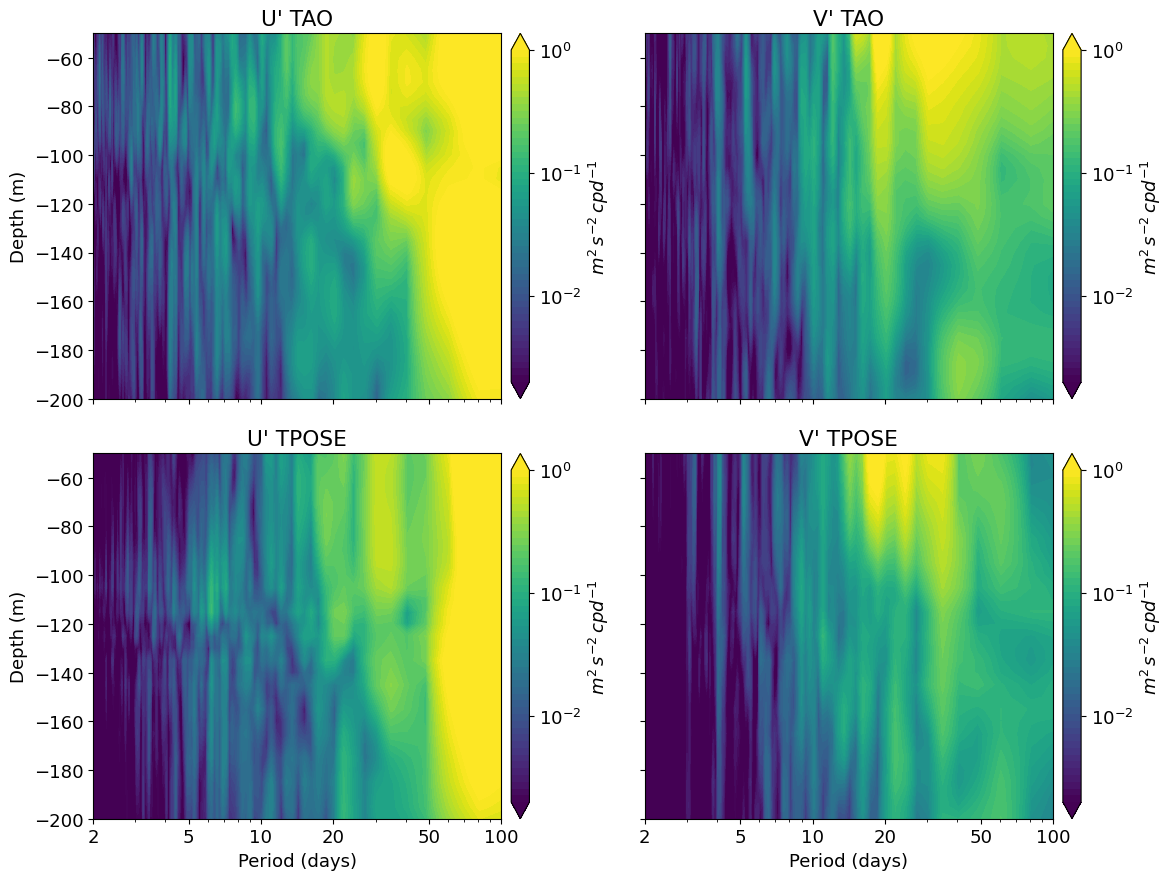

In [8]:
# ---- 2 x 2 contourf: log period axis, log colorscale ----

# Skip DC bin (freq=0) for log-scale x-axis
f_plot  = freqs[1:]          # cpd, 121 values
V_TAO_p = psd_V_TAO[1:, :]  # (121, n_depths)
U_TAO_p = psd_U_TAO[1:, :]
V_TP_p  = psd_V_TP[1:, :]
U_TP_p  = psd_U_TP[1:, :]

# Convert to period (days/cycle) and flip to ascending order for contourf
period_asc = (1.0 / f_plot)[::-1]    # ascending: ~2 → ~243 days/cycle
V_TAO_asc  = V_TAO_p[::-1, :]
U_TAO_asc  = U_TAO_p[::-1, :]
V_TP_asc   = V_TP_p[::-1, :]
U_TP_asc   = U_TP_p[::-1, :]

# Log-spaced contour levels (m^2 s^-2 cpd^-1)
v_vmin, v_vmax = 2e-3, 1e0
u_vmin, u_vmax = 2e-3, 1e0
n_levels = 50
v_levels = np.logspace(np.log10(v_vmin), np.log10(v_vmax), n_levels)
u_levels = np.logspace(np.log10(u_vmin), np.log10(u_vmax), n_levels)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

panels = [
    (axes[0, 1], V_TAO_asc, v_levels, v_vmin, v_vmax, "V\' TAO"),
    (axes[0, 0], U_TAO_asc, u_levels, u_vmin, u_vmax, "U\' TAO"),
    (axes[1, 1], V_TP_asc,  v_levels, v_vmin, v_vmax, "V\' TPOSE"),
    (axes[1, 0], U_TP_asc,  u_levels, u_vmin, u_vmax, "U\' TPOSE"),
]

for ax, psd_asc, levels, vmin, vmax, title in panels:
    cf = ax.contourf(
        period_asc, depths_sel, psd_asc.T,
        levels=levels,
        norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
        cmap='viridis',
        extend='both'
    )
    cb = plt.colorbar(cf, ax=ax, pad=0.02)
    # cb.set_ticks([1e-3, 1e-2, 1e-1, 1e0])
    # cb.set_ticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
    cb.set_ticks([1e-2, 1e-1, 1e0])
    cb.set_ticklabels([r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
    cb.set_label(r'$m^2\,s^{-2}\,cpd^{-1}$')
    ax.set_xscale('log')
    ax.set_xlim(2, 100)
    ax.set_ylim(depths_sel[-1], depths_sel[0])
    ax.set_title(title)

# Clean period tick marks on the shared x-axis
period_ticks = [2, 5, 10, 20, 50, 100]
axes[0, 0].set_xticks(period_ticks)
axes[0, 0].set_xticklabels([str(t) for t in period_ticks])

axes[0, 0].set_ylabel('Depth (m)')
axes[1, 0].set_ylabel('Depth (m)')
axes[1, 0].set_xlabel('Period (days)')
axes[1, 1].set_xlabel('Period (days)')

plt.tight_layout()
plt.savefig('vel_psd_140W_JulFeb_avg.png', dpi=150, bbox_inches='tight')
plt.show()

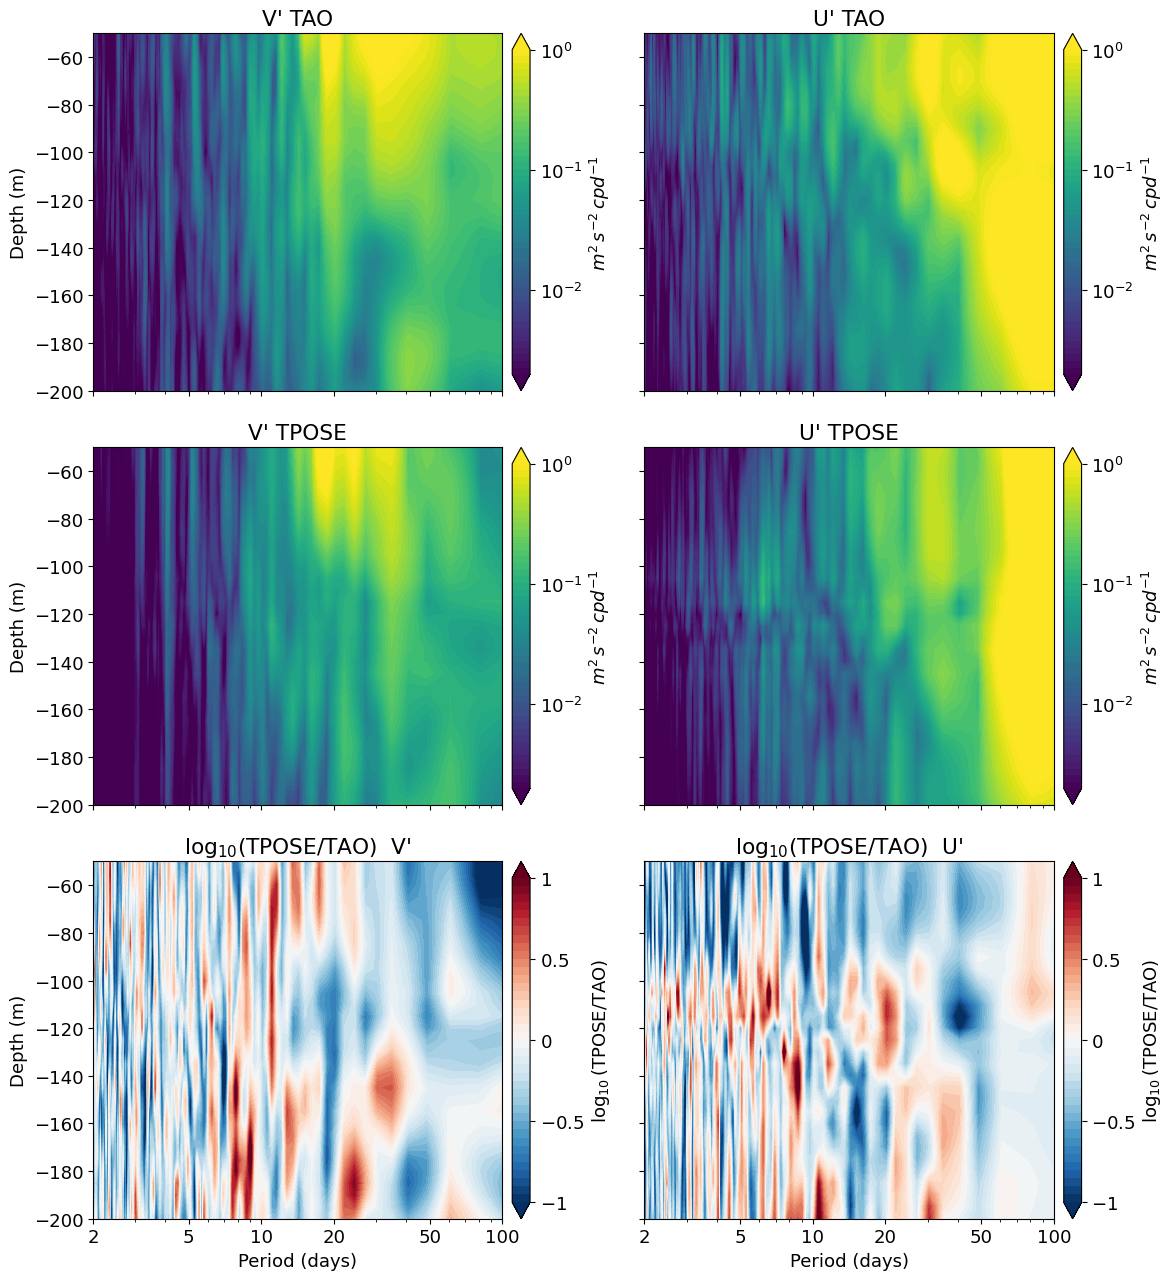

Saved vel_psd_140W_JulFeb_avg_with_diff.png


In [7]:
# ---- 3 x 2 figure: same 4 PSD panels + bottom row showing log10(TPOSE/TAO) ----

eps = 1e-12
diff_V = np.log10(np.clip(V_TP_asc, eps, None) / np.clip(V_TAO_asc, eps, None))
diff_U = np.log10(np.clip(U_TP_asc, eps, None) / np.clip(U_TAO_asc, eps, None))

diff_lim   = 1.0
diff_levels = np.linspace(-diff_lim, diff_lim, 41)

fig2, axes2 = plt.subplots(3, 2, figsize=(12, 13), sharex=True, sharey=True)

# ---- Rows 0-1: same PSD contourf ----
panels2 = [
    (axes2[0, 0], V_TAO_asc, v_levels, v_vmin, v_vmax, "V\' TAO"),
    (axes2[0, 1], U_TAO_asc, u_levels, u_vmin, u_vmax, "U\' TAO"),
    (axes2[1, 0], V_TP_asc,  v_levels, v_vmin, v_vmax, "V\' TPOSE"),
    (axes2[1, 1], U_TP_asc,  u_levels, u_vmin, u_vmax, "U\' TPOSE"),
]

for ax, psd_asc, levels, vmin, vmax, title in panels2:
    cf = ax.contourf(
        period_asc, depths_sel, psd_asc.T,
        levels=levels,
        norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
        cmap='viridis',
        extend='both'
    )
    cb = plt.colorbar(cf, ax=ax, pad=0.02)
    # cb.set_ticks([1e-3, 1e-2, 1e-1, 1e0])
    # cb.set_ticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
    cb.set_ticks([1e-2, 1e-1, 1e0])
    cb.set_ticklabels([r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
    cb.set_label(r'$m^2\,s^{-2}\,cpd^{-1}$')
    ax.set_xscale('log')
    ax.set_xlim(2, 100)
    ax.set_ylim(depths_sel[-1], depths_sel[0])
    ax.set_title(title)

# ---- Row 2: log10(TPOSE / TAO) difference ----
diff_panels = [
    (axes2[2, 0], diff_V, "log$_{10}$(TPOSE/TAO)  V\'"),
    (axes2[2, 1], diff_U, "log$_{10}$(TPOSE/TAO)  U\'"),
]

for ax, diff, title in diff_panels:
    cf = ax.contourf(
        period_asc, depths_sel, diff.T,
        levels=diff_levels,
        cmap='RdBu_r',
        extend='both'
    )
    cb = plt.colorbar(cf, ax=ax, pad=0.02)
    cb.set_ticks([-1, -0.5, 0, 0.5, 1])
    cb.set_ticklabels([r'$-1$', r'$-0.5$', r'$0$', r'$0.5$', r'$1$'])
    cb.set_label(r'$\log_{10}(\mathrm{TPOSE}/\mathrm{TAO})$')
    ax.set_xscale('log')
    ax.set_xlim(2, 100)
    ax.set_ylim(depths_sel[-1], depths_sel[0])
    ax.set_title(title)

# Shared axis labels
period_ticks = [2, 5, 10, 20, 50, 100]
axes2[0, 0].set_xticks(period_ticks)
axes2[0, 0].set_xticklabels([str(t) for t in period_ticks])

for row in range(3):
    axes2[row, 0].set_ylabel('Depth (m)')
axes2[2, 0].set_xlabel('Period (days)')
axes2[2, 1].set_xlabel('Period (days)')

plt.tight_layout()
plt.savefig('vel_psd_140W_JulFeb_avg_with_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved vel_psd_140W_JulFeb_avg_with_diff.png')